# Introduction

## Lab2: Train a Convolutional Neural Network (CNN).

In this Lab session we will learn how to train a CNN from scratch for classifying MNIST digits.

NOTE: All text cells starting with a number indicate that you have to write code or write a response. However, read all the cells to understand the full pipeline.

IMPORTANT: The goal is for you to learn how CNNs are implemented and trained with Pytorch. Using AI to write code for you harms this learning process, so it is strictly forbidden to use AI to write code. Feel free to use AI to _learn_ about Pytorch, CNNs, etc., but you are highly encouraged to read Pytorch's very good documentation, too. Concepts you learn in this assignment will be relevant for the exam.

In [ ]:
# import necessary libraries
import torch
import torchvision
from torchvision import transforms as T
import torch.nn.functional as F

### 1. Define LeNet

![network architecture](https://www.researchgate.net/profile/Lucijano-Berus/publication/329891470/figure/fig1/AS:707347647307776@1545656229128/Architecture-of-LeNet-5-a-Convolutional-Neural-Network-for-digits-digits-recognition-An.ppm)

Here we are going to define our first CNN which is **LeNet** in this case. This architecture has been introduced and is detailed in [this article](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf). To construct a LeNet we will be using two convolutional layers followed by three fully-connected layers as indicated in the figure. The convolutional layers can be defined using `torch.nn.Conv2d` module of `torch.nn` package. Details can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Moreover, we will use a pooling operation to reduce the size of convolutional feature maps. For this case we are going to use `torch.nn.functional.max_pool2d`. Details about maxpooling can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.max_pool2d.html)

Differently from our previous Lab, we will use a Rectified Linear Units (ReLU) as activation function with the help of `torch.nn.functional.relu`, replacing `torch.nn.Sigmoid`. Details about ReLU can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.relu.html).

Note: The figure shows 32x32 input size while your data will be slightly differnt. You can either pad the input or adjust the network architecture slightly (as little as possible).

In [ ]:
from torch.nn.modules.activation import Tanh
class LeNet(torch.nn.Module):
  def __init__(self, channels=1, padding=0):
    super(LeNet, self).__init__()

    self.conv1 = torch.nn.Conv2d(channels, 6, 5, padding=padding)
    self.conv2 = torch.nn.Conv2d(6, 16, 5)
    self.tanh = Tanh()
    self.linear1 = torch.nn.Linear(16*5*5, 120)
    self.linear2 = torch.nn.Linear(120, 84)
    self.linear3 = torch.nn.Linear(84, 10)

  def forward(self, x):
    # TODO
    # Max Pooling with kernel size = 2
    # output size = (6, 14, 14)
    # TODO

    x=F.max_pool2d(self.conv1(x), 2)

    # TODO
    # Max Pooling with kernel size = 2
    # output size = (16, 5, 5)
    # TODO
    x=F.max_pool2d(self.conv2(x), 2)

    # flatten the feature maps into a long vector
    x = x.view(x.shape[0], -1)

    # TODO
    x = F.relu(self.linear1(x))
    # TODO
    x = self.tanh(self.linear2(x))
    # TODO
    x = self.linear3(x)
    return x

### 2. Define cost function
Hint: Make sure to read the documentation of the loss function you use to validate that your network output matches what the loss expects as input.

In [ ]:
def get_cost_function():
  cost_function = torch.nn.CrossEntropyLoss()# TODO
  return cost_function

### 3. Define the optimizer

We will use SGD with learning rate-lr, weight_decay=wd and  momentum=momentum

In [ ]:
def get_optimizer(net, lr, wd, momentum):
  optimizer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd, momentum=momentum)
  return optimizer

### Train and test functions

In [ ]:
def test(net, data_loader, cost_function, device='cuda:0'):
  samples = 0.
  cumulative_loss = 0.
  cumulative_accuracy = 0.

  net.eval() # Strictly needed if network contains layers which has different behaviours between train and test
  with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(data_loader):
      # Load data into GPU
      inputs = inputs.to(device)
      targets = targets.to(device)

      # Forward pass
      outputs = net(inputs)

      # Apply the loss
      loss = cost_function(outputs, targets)

      # Better print something
      samples+=inputs.shape[0]
      cumulative_loss += loss.item() # Note: the .item() is needed to extract scalars from tensors
      _, predicted = outputs.max(1)
      cumulative_accuracy += predicted.eq(targets).sum().item()

  return cumulative_loss/samples, cumulative_accuracy/samples*100


def train(net,data_loader,optimizer,cost_function, device='cuda:0'):
  samples = 0.
  cumulative_loss = 0.
  cumulative_accuracy = 0.


  net.train() # Strictly needed if network contains layers which has different behaviours between train and test
  for batch_idx, (inputs, targets) in enumerate(data_loader):
    # Load data into GPU
    inputs = inputs.to(device)
    targets = targets.to(device)

    # Forward pass
    outputs = net(inputs)

    # Apply the loss
    loss = cost_function(outputs,targets)

    # Reset the optimizer
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update parameters
    optimizer.step()

    # Better print something, no?
    samples+=inputs.shape[0]
    cumulative_loss += loss.item()
    _, predicted = outputs.max(1)
    cumulative_accuracy += predicted.eq(targets).sum().item()

  return cumulative_loss/samples, cumulative_accuracy/samples*100

### Define the function that fetches a data loader that is then used during iterative training.

We will learn a new thing in this function as how to Normalize the inputs given to the network.

***Why Normalization is needed***?

To have nice and stable training of the network it is recommended to normalize the network inputs between \[-1, 1\].

***How it can be done***?

This can be simply done using `torchvision.transforms.Normalize()` transform. Details can be found [here](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.Normalize.html).

In [ ]:
def get_data(batch_size, test_batch_size=256):

  # Prepare data transformations and then combine them sequentially
  transform = list()
  transform.append(T.ToTensor())                            # converts Numpy to Pytorch Tensor
  transform.append(T.Normalize(mean=[0.5], std=[0.5]))      # Normalizes the Tensors between [-1, 1]
  transform = T.Compose(transform)                          # Composes the above transformations into one.

  # Load data
  full_training_data = torchvision.datasets.MNIST('./data', train=True, transform=transform, download=True)
  test_data = torchvision.datasets.MNIST('./data', train=False, transform=transform, download=True)


  # Create train and validation splits
  num_samples = len(full_training_data)
  training_samples = int(num_samples*0.5+1)
  validation_samples = num_samples - training_samples

  training_data, validation_data = torch.utils.data.random_split(full_training_data, [training_samples, validation_samples])

  # Initialize dataloaders
  train_loader = torch.utils.data.DataLoader(training_data, batch_size, shuffle=True)
  val_loader = torch.utils.data.DataLoader(validation_data, test_batch_size, shuffle=False)
  test_loader = torch.utils.data.DataLoader(test_data, test_batch_size, shuffle=False)

  return train_loader, val_loader, test_loader

### 4. Initializing model and wrapping everything up

Finally, we need a main function which initializes everything + the needed hyperparameters and loops over multiple epochs (printing the results).

In [ ]:
'''
Input arguments
  batch_size: Size of a mini-batch
  device: GPU where you want to train your network
  weight_decay: Weight decay co-efficient for regularization of weights
  momentum: Momentum for SGD optimizer
  epochs: Number of epochs for training the network
'''

def main(net, batch_size=128,
         device='cuda:0',
         learning_rate=0.01,
         weight_decay=0.000001,
         momentum=0.9,
         epochs=50):
  train_accs = []; val_accs = []; train_losses = []; val_losses = []
  train_loader, val_loader, test_loader = get_data(batch_size)

  # TODO for defining LeNet-5 and moving it to the GPU

  optimizer = get_optimizer(net, learning_rate, weight_decay, momentum)

  cost_function = get_cost_function()

  print('Before training:')
  train_loss, train_accuracy = test(net, train_loader, cost_function)
  val_loss, val_accuracy = test(net, val_loader, cost_function)
  test_loss, test_accuracy = test(net, test_loader, cost_function)
  train_losses.append(train_loss); val_losses.append(test_loss)
  train_accs.append(train_accuracy); val_accs.append(test_accuracy)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')

  for e in range(epochs):
    train_loss, train_accuracy = train(net, train_loader, optimizer, cost_function)
    val_loss, val_accuracy = test(net, val_loader, cost_function)
    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_accuracy); val_accs.append(val_accuracy)
    print('Epoch: {:d}'.format(e+1))
    print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
    print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
    print('-----------------------------------------------------')

  print('After training:')
  train_loss, train_accuracy = test(net, train_loader, cost_function)
  val_loss, val_accuracy = test(net, val_loader, cost_function)
  test_loss, test_accuracy = test(net, test_loader, cost_function)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')
  return train_accs, val_accs, train_losses, val_losses


Lets train!

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = LeNet(padding=2).to(device)
train_accs, val_accs, train_losses, val_losses=main(net)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.49MB/s]


Before training:
	 Training loss 0.01807, Training accuracy 9.60
	 Validation loss 0.00908, Validation accuracy 9.68
	 Test loss 0.00923, Test accuracy 9.48
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00628, Training accuracy 74.64
	 Validation loss 0.00080, Validation accuracy 93.93
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00121, Training accuracy 95.38
	 Validation loss 0.00048, Validation accuracy 96.34
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00078, Training accuracy 97.06
	 Validation loss 0.00041, Validation accuracy 96.92
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00061, Training accuracy 97.62
	 Validation loss 0.00036, Validation accuracy 97.17
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00048, Training accuracy 98.17
	 Validation loss 0.00031, Validation accuracy 97.59
------------------

#### Optional: Plot the training and validation curves.



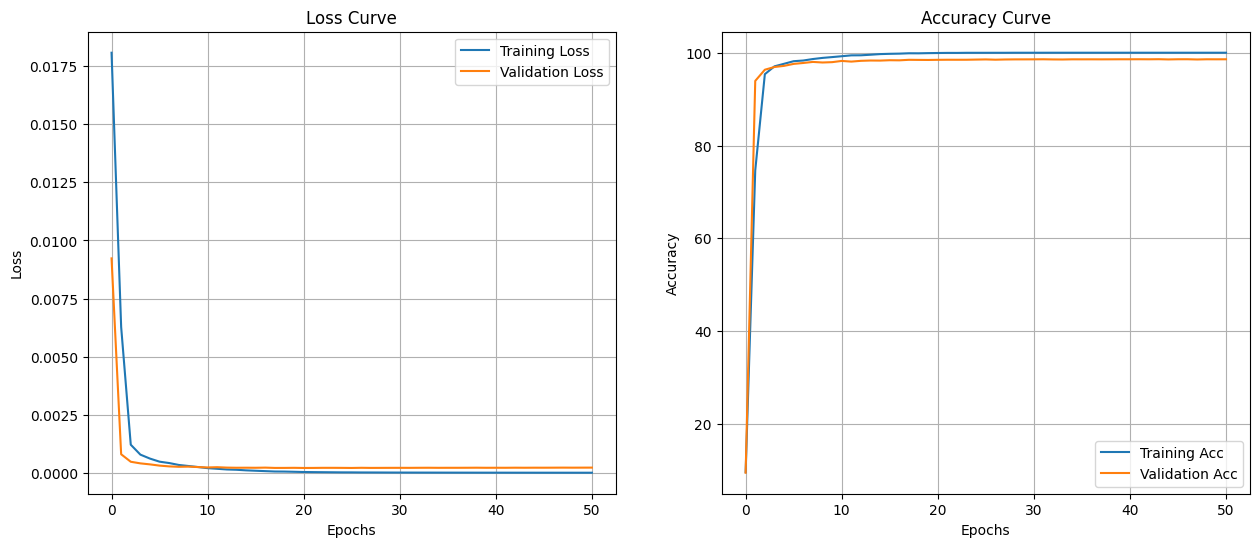

In [ ]:
# --- OPTIONAL : Plot the training and validation curves
import matplotlib.pyplot as plt

def plot_curves(train_accs, val_accs, train_losses, val_losses):
  fig, axes=plt.subplots(1,2, figsize=(15 ,6))
  axes[0].plot(train_losses)
  axes[0].plot(val_losses)
  axes[0].set_xlabel('Epochs')
  axes[0].set_ylabel('Loss')
  axes[0].set_title('Loss Curve')
  axes[0].grid('True')
  axes[0].legend(['Training Loss', 'Validation Loss'])


  axes[1].plot(train_accs)
  axes[1].plot(val_accs)
  axes[1].set_xlabel('Epochs')
  axes[1].set_ylabel('Accuracy')
  axes[1].set_title('Accuracy Curve')
  axes[1].grid('True')
  axes[1].legend(['Training Acc', 'Validation Acc'], loc='lower right')

  plt.show()
plot_curves(train_accs, val_accs, train_losses, val_losses)

### 5. Plot a confusion matrix to check which MNIST digit is most frequently confused with which other digit. Can you explain why?


**ANSWER :** Based on the confusion matrix, the digit that has the greater non diagonal element is 7. (3rd column of the 7th row). So 7 is confused with 3.


[[ 974    0    0    0    0    1    3    0    1    1]
 [   0 1125    3    3    0    0    2    0    2    0]
 [   1    1 1021    1    1    0    0    3    4    0]
 [   0    0    2  995    0    5    0    1    3    4]
 [   0    0    2    0  970    0    2    3    1    4]
 [   3    0    0    4    0  880    3    0    1    1]
 [   3    2    0    0    2    5  945    0    1    0]
 [   0    0    7    2    1    0    0 1013    1    4]
 [   2    0    2    5    1    0    0    2  960    2]
 [   3    1    0    4    8    3    0    4    2  984]]


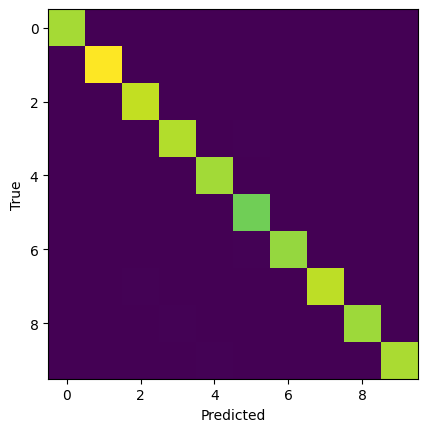

In [ ]:
from sklearn.metrics import confusion_matrix

_, _, test_loader=get_data(128)
preds = []; labels = []
net.eval()
with torch.no_grad():
  for (X,y) in test_loader:
    X = X.to(device)
    y = y.to(device)
    pred = net(X)
    preds.extend(pred.argmax(1).cpu().numpy())
    labels.extend(y.cpu().numpy())

cm=confusion_matrix(labels,preds)
print(cm)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.imshow(cm)

### For the remaining tasks try to integrate the changes in the code above while avoiding duplicate code as much as possible. For every task, introduce flags (i.e., function arguments) to the main() function to enable the new functionality of the task. It should always be possible to run the original implementation above. Finally, call the main function with the correct flags for each task in the cells below.

### 6. The LeNet5 architecture can also be implemented using the sequential API ([see documentation](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)). Reimplement it with this API and run training + evaluation once to verify it works.

In [ ]:
class LeNet_API(torch.nn.Module):
  def __init__(self):
    super(LeNet_API, self).__init__()

    self.model=torch.nn.Sequential(
        torch.nn.Conv2d(1, 6, 5, padding=2),
        torch.nn.MaxPool2d(2),
        torch.nn.Conv2d(6, 16, 5),
        torch.nn.MaxPool2d(2),
        torch.nn.Flatten(),
        torch.nn.Linear(16*5*5, 120),
        torch.nn.ReLU(),
        torch.nn.Linear(120, 84),
        torch.nn.Tanh(),
        torch.nn.Linear(84, 10)
    )

  def forward(self, x):

    x_tensor = torch.asarray(x, dtype=torch.float)
    hat_y = self.model(x_tensor)

    return hat_y

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = LeNet_API().to(device)
train_accs, val_accs, train_losses, val_losses=main(net, epochs=1)

Before training:
	 Training loss 0.01803, Training accuracy 11.16
	 Validation loss 0.00906, Validation accuracy 11.32
	 Test loss 0.00921, Test accuracy 11.37
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00657, Training accuracy 74.56
	 Validation loss 0.00070, Validation accuracy 94.71
-----------------------------------------------------
After training:
	 Training loss 0.00136, Training accuracy 94.93
	 Validation loss 0.00070, Validation accuracy 94.71
	 Test loss 0.00063, Test accuracy 95.29
-----------------------------------------------------


### 7. Implement adaptive early stopping: if the validation loss did not decrease for K consecutive epochs, stop training.
#### Optional: Select the model based on the best validation loss.

Before training:
	 Training loss 0.01805, Training accuracy 11.52
	 Validation loss 0.00906, Validation accuracy 11.66
	 Test loss 0.00922, Test accuracy 11.89
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00593, Training accuracy 76.74
	 Validation loss 0.00080, Validation accuracy 93.92
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00118, Training accuracy 95.48
	 Validation loss 0.00048, Validation accuracy 96.37
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00075, Training accuracy 97.18
	 Validation loss 0.00042, Validation accuracy 96.75
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00055, Training accuracy 97.90
	 Validation loss 0.00031, Validation accuracy 97.55
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00044, Training accuracy 98.34
	 Validation loss 0.00027, Validation accuracy 97.96
---------------

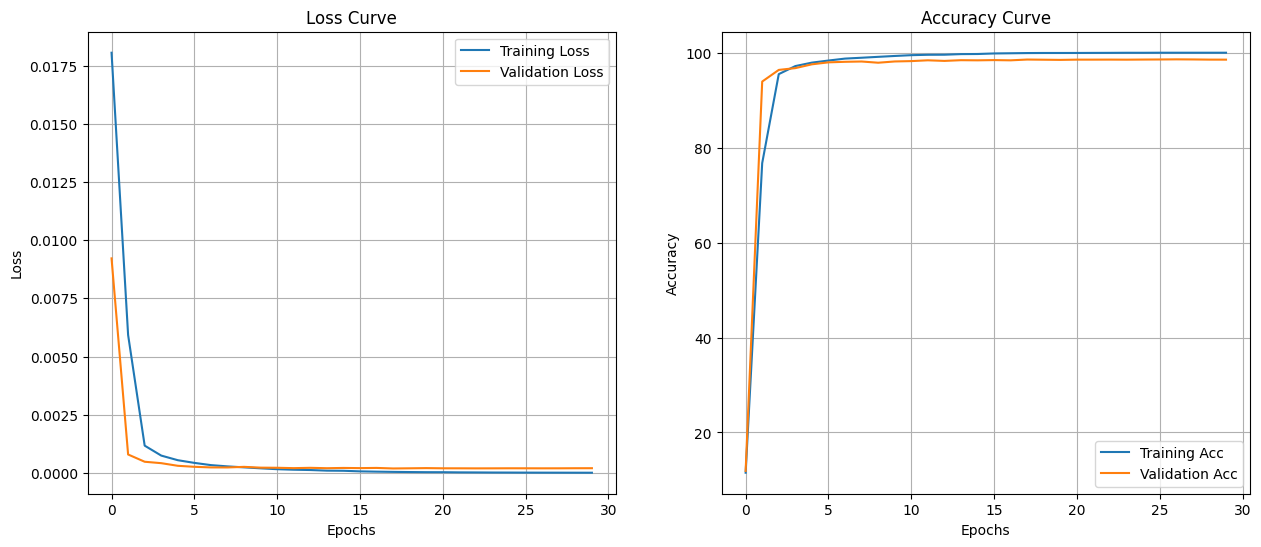

In [13]:
'''
Input arguments
  batch_size: Size of a mini-batch
  device: GPU where you want to train your network
  weight_decay: Weight decay co-efficient for regularization of weights
  momentum: Momentum for SGD optimizer
  epochs: Number of epochs for training the network
'''

def main_early_stop(net, batch_size=128,
         device='cuda:0',
         learning_rate=0.01,
         weight_decay=0.000001,
         momentum=0.9,
         epochs=50, earlystop = 3):
  K = 0
  train_accs = []; val_accs = []; train_losses = []; val_losses = []
  train_loader, val_loader, test_loader = get_data(batch_size)

  # TODO for defining LeNet-5 and moving it to the GPU

  optimizer = get_optimizer(net, learning_rate, weight_decay, momentum)

  cost_function = get_cost_function()

  print('Before training:')
  train_loss, train_accuracy = test(net, train_loader, cost_function)
  val_loss, val_accuracy = test(net, val_loader, cost_function)
  test_loss, test_accuracy = test(net, test_loader, cost_function)
  train_losses.append(train_loss); val_losses.append(test_loss)
  train_accs.append(train_accuracy); val_accs.append(test_accuracy)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')

  for e in range(epochs):
    train_loss, train_accuracy = train(net, train_loader, optimizer, cost_function)
    val_loss, val_accuracy = test(net, val_loader, cost_function)
    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_accuracy); val_accs.append(val_accuracy)
    if val_losses[-2]<=val_losses[-1]:
      K+=1
    else:
      K=0
    print('Epoch: {:d}'.format(e+1))
    print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
    print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
    print('-----------------------------------------------------')
    if K==earlystop:
      print(f"Early stopping at epoch {e} ----------------\n")
      break

  print('After training:')
  train_loss, train_accuracy = test(net, train_loader, cost_function)
  val_loss, val_accuracy = test(net, val_loader, cost_function)
  test_loss, test_accuracy = test(net, test_loader, cost_function)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')
  return train_accs, val_accs, train_losses, val_losses

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = LeNet(padding=2).to(device)
train_accs, val_accs, train_losses, val_losses=main_early_stop(net)
plot_curves(train_accs, val_accs, train_losses, val_losses)

### 8. Change the dataset in order to train and evaluate the LeNet5 network on [CIFAR10](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html).

Before training:
	 Training loss 0.01808, Training accuracy 9.67
	 Validation loss 0.00904, Validation accuracy 9.18
	 Test loss 0.00923, Test accuracy 9.65
-----------------------------------------------------
Epoch: 1
	 Training loss 0.01652, Training accuracy 22.68
	 Validation loss 0.00736, Validation accuracy 31.41
-----------------------------------------------------
Epoch: 2
	 Training loss 0.01360, Training accuracy 37.52
	 Validation loss 0.00621, Validation accuracy 42.95
-----------------------------------------------------
Epoch: 3
	 Training loss 0.01185, Training accuracy 45.73
	 Validation loss 0.00565, Validation accuracy 47.86
-----------------------------------------------------
Epoch: 4
	 Training loss 0.01098, Training accuracy 49.61
	 Validation loss 0.00543, Validation accuracy 50.45
-----------------------------------------------------
Epoch: 5
	 Training loss 0.01029, Training accuracy 53.17
	 Validation loss 0.00521, Validation accuracy 52.19
------------------

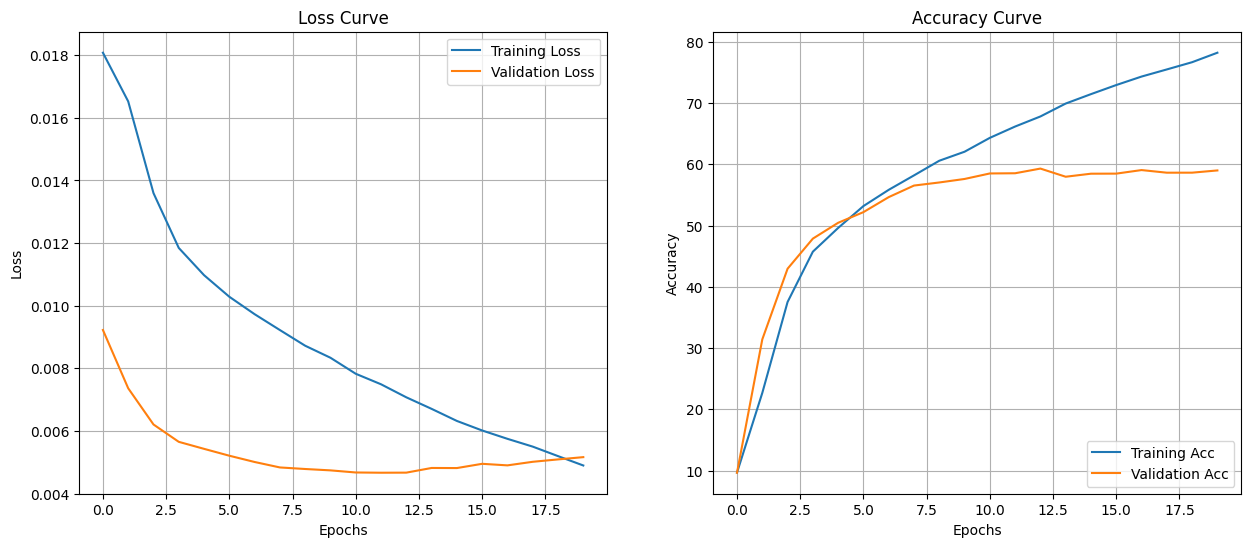

In [21]:
def get_data(batch_size, test_batch_size=256):

  # Prepare data transformations and then combine them sequentially
  transform = list()
  transform.append(T.ToTensor())                            # converts Numpy to Pytorch Tensor
  transform.append(T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5 ]))      # Normalizes the Tensors between [-1, 1]
  transform = T.Compose(transform)                          # Composes the above transformations into one.

  # Load data
  full_training_data = torchvision.datasets.CIFAR10('./data', train=True, transform=transform, download=True)
  test_data = torchvision.datasets.CIFAR10('./data', train=False, transform=transform, download=True)


  # Create train and validation splits
  num_samples = len(full_training_data)
  training_samples = int(num_samples*0.5+1)
  validation_samples = num_samples - training_samples

  training_data, validation_data = torch.utils.data.random_split(full_training_data, [training_samples, validation_samples])

  # Initialize dataloaders
  train_loader = torch.utils.data.DataLoader(training_data, batch_size, shuffle=True)
  val_loader = torch.utils.data.DataLoader(validation_data, test_batch_size, shuffle=False)
  test_loader = torch.utils.data.DataLoader(test_data, test_batch_size, shuffle=False)

  return train_loader, val_loader, test_loader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = LeNet(channels=3).to(device)
train_accs, val_accs, train_losses, val_losses=main_early_stop(net)
plot_curves(train_accs, val_accs, train_losses, val_losses)

### 9. Try to improve the performance on CIFAR10 with both:
   *   data-augmentation
   *   dropout

In [22]:
class LeNet_dropout(torch.nn.Module):
  def __init__(self, channels=1, padding=0):
    super(LeNet_dropout, self).__init__()

    self.conv1 = torch.nn.Conv2d(channels, 6, 5, padding=padding)
    self.conv2 = torch.nn.Conv2d(6, 16, 5)
    self.tanh = Tanh()
    self.linear1 = torch.nn.Linear(16*5*5, 120)
    self.linear2 = torch.nn.Linear(120, 84)
    self.linear3 = torch.nn.Linear(84, 10)
    self.dropout = torch.nn.Dropout(0.25)

  def forward(self, x):

    x=F.max_pool2d(self.conv1(x), 2)
    x=F.max_pool2d(self.conv2(x), 2)
    x = x.view(x.shape[0], -1)
    x = F.relu(self.linear1(x))
    x = self.tanh(self.linear2(x))
    x = self.dropout(x)
    x = self.linear3(x)
    return x

Before training:
	 Training loss 0.01804, Training accuracy 9.93
	 Validation loss 0.00922, Validation accuracy 9.76
	 Test loss 0.00922, Test accuracy 9.77
-----------------------------------------------------
Epoch: 1
	 Training loss 0.01605, Training accuracy 24.38
	 Validation loss 0.00737, Validation accuracy 32.41
-----------------------------------------------------
Epoch: 2
	 Training loss 0.01339, Training accuracy 37.93
	 Validation loss 0.00641, Validation accuracy 41.78
-----------------------------------------------------
Epoch: 3
	 Training loss 0.01220, Training accuracy 43.05
	 Validation loss 0.00597, Validation accuracy 45.54
-----------------------------------------------------
Epoch: 4
	 Training loss 0.01150, Training accuracy 46.80
	 Validation loss 0.00580, Validation accuracy 47.23
-----------------------------------------------------
Epoch: 5
	 Training loss 0.01107, Training accuracy 49.28
	 Validation loss 0.00544, Validation accuracy 51.54
------------------

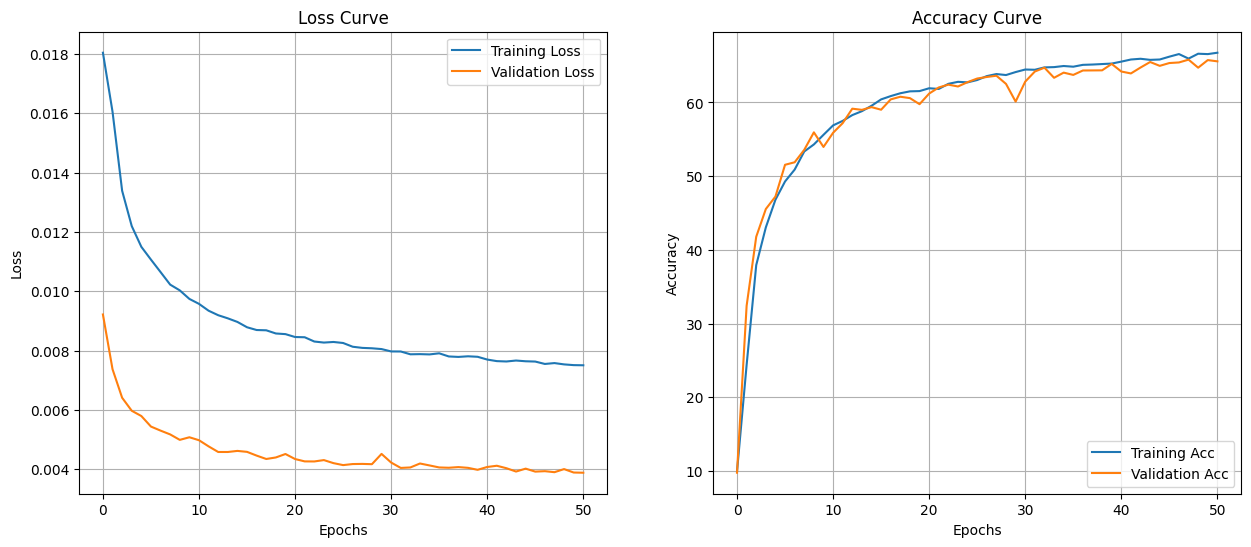

In [23]:
def get_data(batch_size, test_batch_size=256):

  # Prepare data transformations and then combine them sequentially
  test_transform = list()
  test_transform.append(T.ToTensor())                            # converts Numpy to Pytorch Tensor
  test_transform.append(T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]))      # Normalizes the Tensors between [-1, 1]
  test_transform = T.Compose(test_transform)                          # Composes the above transformations into one.

  train_transform = list()
  train_transform.append(T.RandomCrop(32, padding=4))
  train_transform.append(T.RandomHorizontalFlip(p=0.5))
  train_transform.append(T.ToTensor())                            # converts Numpy to Pytorch Tensor
  train_transform.append(T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]))      # Normalizes the Tensors between [-1, 1]
  train_transform = T.Compose(train_transform)                          # Composes the above transformations into one.

  # Load data
  full_training_data = torchvision.datasets.CIFAR10('./data', train=True, transform=train_transform, download=True)
  test_data = torchvision.datasets.CIFAR10('./data', train=False, transform=test_transform, download=True)


  # Create train and validation splits
  num_samples = len(full_training_data)
  training_samples = int(num_samples*0.8)
  validation_samples = num_samples - training_samples

  training_data, validation_data = torch.utils.data.random_split(full_training_data, [training_samples, validation_samples])

  # Initialize dataloaders
  train_loader = torch.utils.data.DataLoader(training_data, batch_size, shuffle=True)
  val_loader = torch.utils.data.DataLoader(validation_data, test_batch_size, shuffle=False)
  test_loader = torch.utils.data.DataLoader(test_data, test_batch_size, shuffle=False)

  return train_loader, val_loader, test_loader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = LeNet_dropout(channels=3).to(device)
train_accs, val_accs, train_losses, val_losses=main_early_stop(net)
plot_curves(train_accs, val_accs, train_losses, val_losses)

**Comment:** We see that, in the end, we get a better test accuracy than before. So the performance on CIFAR10 has improved after implementing data augmentation and dropout.

### 10. Use the ResNet18 class from Pytorch to train and evaluate a ResNet on CIFAR10 (make sure it works, but if it takes too long, you don't have to train until convergence).

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


Before training:
	 Training loss 0.01898, Training accuracy 9.44
	 Validation loss 0.00972, Validation accuracy 9.15
	 Test loss 0.00985, Test accuracy 10.09
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00879, Training accuracy 61.44
	 Validation loss 0.00336, Validation accuracy 70.91
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00583, Training accuracy 74.61
	 Validation loss 0.00274, Validation accuracy 76.37
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00512, Training accuracy 77.75
	 Validation loss 0.00274, Validation accuracy 76.75
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00460, Training accuracy 79.57
	 Validation loss 0.00240, Validation accuracy 79.26
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00426, Training accuracy 81.27
	 Validation loss 0.00233, Validation accuracy 79.85
-----------------

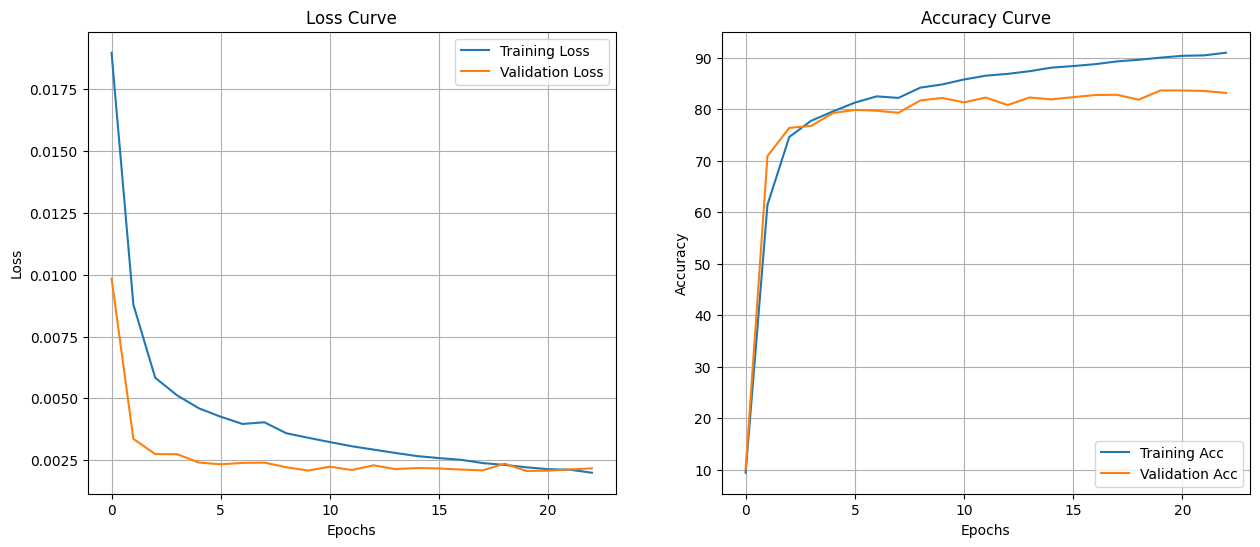

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = torchvision.models.resnet18(weights='DEFAULT')
num_ftrs = net.fc.in_features
net.fc = torch.nn.Linear(num_ftrs, 10)
net=net.to(device)

train_accs, val_accs, train_losses, val_losses=main_early_stop(net)
plot_curves(train_accs, val_accs, train_losses, val_losses)
